In [21]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

df = pd.read_csv('Flourishing_N317_v2.csv')

# Step 1: Encode missing values (handle 0 and 7)
# Define demographic and text identifier columns to exclude
exclude_cols = ['AGE', 'SEX', 'NBENFANT', 'ANCIENNETE', 'TAILLE', 'SITUFAM', 'NIVEAUETUDE']

# Get columns where 0 should be replaced with NaN, perform 0 -> NaN replacement
cols_for_zero = [col for col in df.columns if col not in exclude_cols]
df[cols_for_zero] = df[cols_for_zero].replace(0, np.nan)

# Get all columns starting from 'MHCB1', perform 7 -> NaN replacement
start_idx = df.columns.get_loc('MHCB1')
scale_cols = df.columns[start_idx:]
df[scale_cols] = df[scale_cols].replace(7, np.nan)

# Step 2: Remove rows/columns with >50% missing values
# 1. Remove rows with >50% missing values
row_thresh = int(df.shape[1] * 0.5)
df = df.dropna(thresh=row_thresh, axis=0)

# 2. Remove columns with >50% missing values
col_thresh = int(df.shape[0] * 0.5)
df = df.dropna(thresh=col_thresh, axis=1)

# Step 3: KNN mean imputation (for scale items only)
knn_cols = [col for col in scale_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
imputer = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer.fit_transform(df[knn_cols])
df[knn_cols] = df[knn_cols].round(0)

# 1. Predefine adaptive categorization function (fix NameError)
def adaptive_categorize(row, ewb_cols, func_cols):
    valid_ewb = [c for c in ewb_cols if c in row.index and pd.notna(row[c])]
    valid_func = [c for c in func_cols if c in row.index and pd.notna(row[c])]
    
    if not valid_ewb or not valid_func:
        return np.nan
        
    # Dynamic threshold logic: Keyes (2002) original standard = 6/11 (54.5%)
    func_threshold = max(1, int(round(len(valid_func) * (6.0 / 11.0))))
    ewb_threshold = 1 
    
    is_flourishing = (sum(row[valid_ewb] >= 5) >= ewb_threshold) and (sum(row[valid_func] >= 5) >= func_threshold)
    is_languishing = (sum(row[valid_ewb] <= 2) >= ewb_threshold) and (sum(row[valid_func] <= 2) >= func_threshold)
    
    if is_flourishing: return 'Flourishing'
    if is_languishing: return 'Languishing'
    return 'Moderate'

# 2. Extract items and apply function for calculation
mhcb_ewb = ['MHCB1', 'MHCB2', 'MHCB3']
mhcb_func = [c for c in df.columns if c.startswith('MHCB') and c not in mhcb_ewb]

mhcc_ewb = ['MHCC1', 'MHCC2', 'MHCC3']
mhcc_func = [c for c in df.columns if c.startswith('MHCC') and c not in mhcc_ewb]

# Apply function to generate mental state text labels
df['Flourishing_Work'] = df.apply(lambda r: adaptive_categorize(r, mhcb_ewb, mhcb_func), axis=1)
df['Flourishing_Private'] = df.apply(lambda r: adaptive_categorize(r, mhcc_ewb, mhcc_func), axis=1)

# 3. Explicitly convert to strict Pandas Categorical Type
flourish_cats = pd.CategoricalDtype(
    categories=['Languishing', 'Moderate', 'Flourishing'], 
    ordered=True
)

df['Flourishing_Work'] = df['Flourishing_Work'].astype(flourish_cats)
df['Flourishing_Private'] = df['Flourishing_Private'].astype(flourish_cats)

# 4. Emotional Status calculation and type conversion
pe_cols = [c for c in df.columns if c.startswith('PE')]
ne_cols = [c for c in df.columns if c.startswith('NE')]
df['Positivity_Ratio'] = df[pe_cols].mean(axis=1) / df[ne_cols].mean(axis=1).replace(0, 0.01)

def get_emotional_status(ratio):
    if pd.isna(ratio): return np.nan
    if ratio > 3: return 'Emotionally Flourishing'
    if 2 <= ratio <= 3: return 'Moderately Healthy'
    if 1 <= ratio < 2: return 'Emotionally Languishing'
    return 'Depressed'

df['Emotional_Status_Text'] = df['Positivity_Ratio'].apply(get_emotional_status)

emotion_cats = pd.CategoricalDtype(
    categories=['Depressed', 'Emotionally Languishing', 'Moderately Healthy', 'Emotionally Flourishing'], 
    ordered=True
)

df['Emotional_Status'] = df['Emotional_Status_Text'].astype(emotion_cats)
df = df.drop(columns=['Emotional_Status_Text'])

output_file = 'Flourishing_Processed_Part1.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Processing complete! Cleaned data saved to: {output_file}")
print(f"Data summary: Retained {df.shape[0]} rows and {df.shape[1]} variables.")

Processing complete! Cleaned data saved to: Flourishing_Processed_Part1.csv
Data summary: Retained 284 rows and 66 variables.


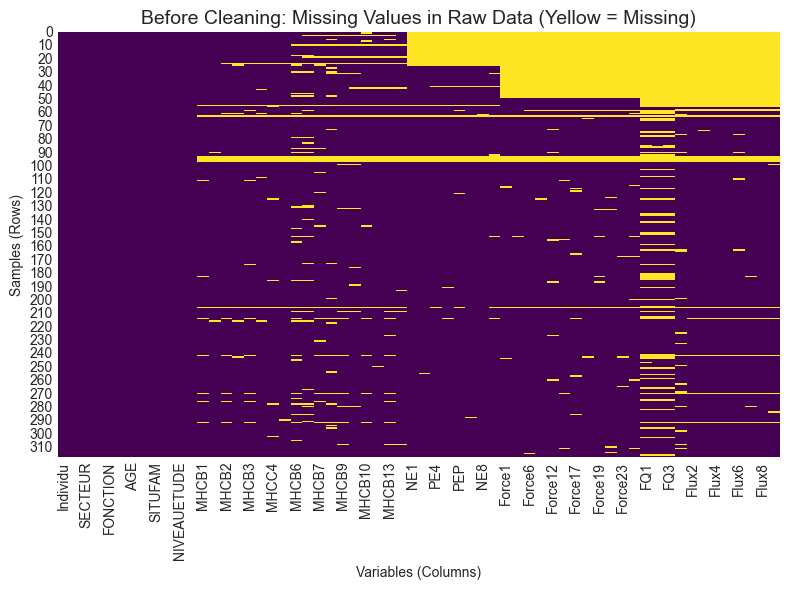

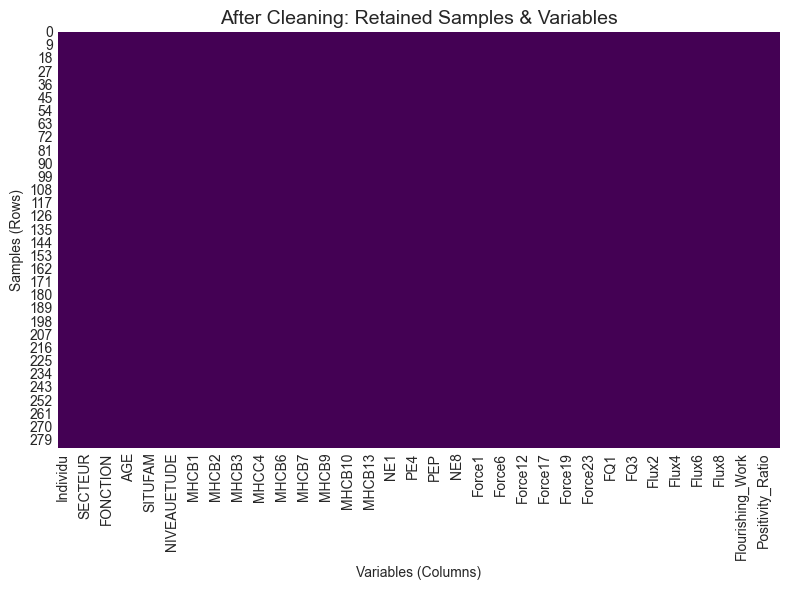

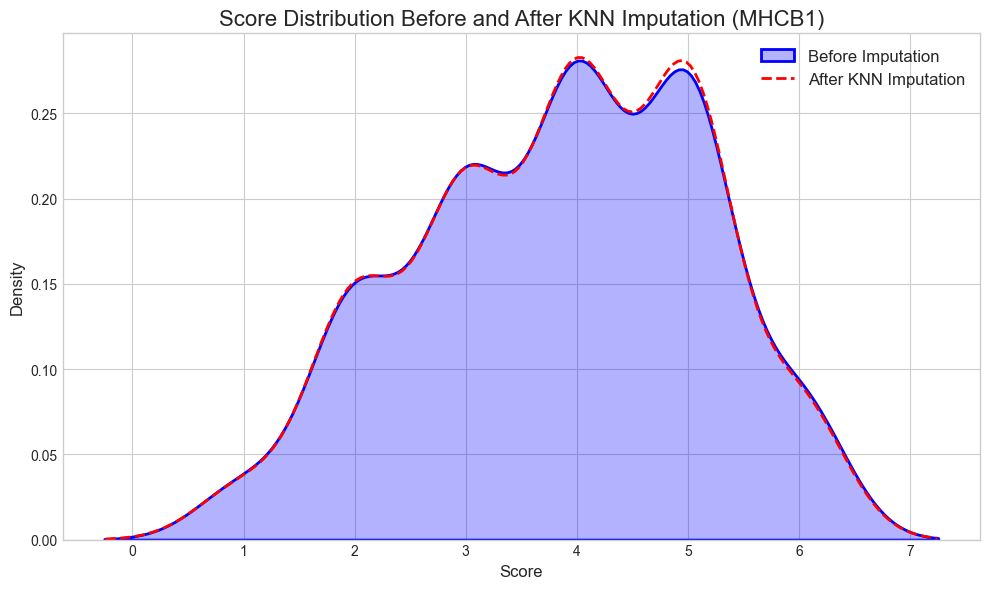

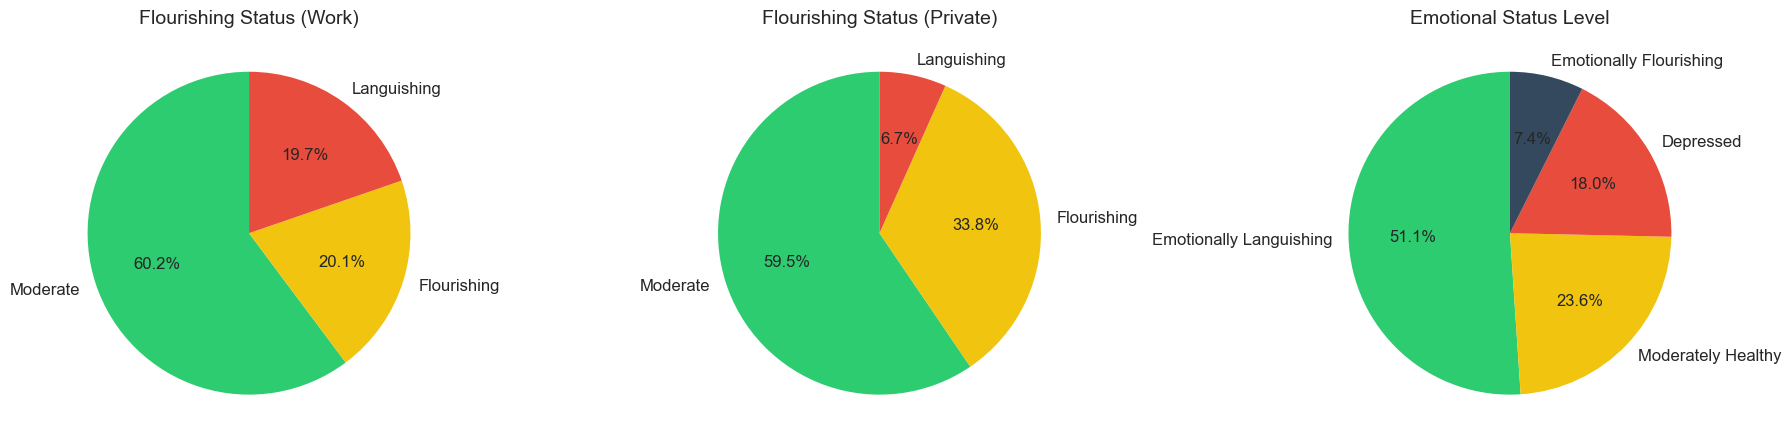

In [20]:
plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 
df_raw = pd.read_csv('Flourishing_N317_v2.csv')
exclude_cols = ['AGE', 'SEX', 'NBENFANT', 'ANCIENNETE', 'TAILLE', 'SITUFAM', 'NIVEAUETUDE', 
                'Individu', 'GUI', 'SECTEUR', 'FONCTION', 'FORMATION']

# Replace 0 and 7 to show true missing pattern
cols_for_zero = [c for c in df_raw.columns if c not in exclude_cols]
df_raw_missing = df_raw.copy()
df_raw_missing[cols_for_zero] = df_raw_missing[cols_for_zero].replace(0, np.nan)
start_idx = df_raw.columns.get_loc('MHCB1')
scale_cols = df_raw.columns[start_idx:]
df_raw_missing[scale_cols] = df_raw_missing[scale_cols].replace(7, np.nan)

# Load cleaned final data
df_clean = pd.read_csv('Flourishing_Processed_Part1.csv')


# Figure 1a: Missing value distribution heatmap (Before Cleaning)
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw_missing.isnull(), cbar=False, cmap='viridis')
plt.title('Before Cleaning: Missing Values in Raw Data (Yellow = Missing)', fontsize=14)
plt.xlabel('Variables (Columns)')
plt.ylabel('Samples (Rows)')
plt.tight_layout()
plt.show()


# Figure 1b: Retained samples and variables (After Cleaning)
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis')
plt.title('After Cleaning: Retained Samples & Variables', fontsize=14)
plt.xlabel('Variables (Columns)')
plt.ylabel('Samples (Rows)')
plt.tight_layout()
plt.show()


# Figure 2: KDE comparison before and after KNN imputation
target_col = 'MHCB1'
# Extract data before imputation
row_thresh = int(df_raw_missing.shape[1] * 0.5)
df_temp = df_raw_missing.dropna(thresh=row_thresh, axis=0)
col_thresh = int(df_temp.shape[0] * 0.5)
df_temp = df_temp.dropna(thresh=col_thresh, axis=1)

plt.figure(figsize=(10, 6))
# Plot distribution before imputation (drop NaN)
sns.kdeplot(df_temp[target_col].dropna(), color='blue', label='Before Imputation', linewidth=2, fill=True, alpha=0.3)
# Plot distribution after imputation
sns.kdeplot(df_clean[target_col], color='red', label='After KNN Imputation', linewidth=2, linestyle='--')

plt.title(f'Score Distribution Before and After KNN Imputation ({target_col})', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Figure 3: Pie charts for flourishing status and emotional level distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#34495e']

# Subplot 1: Work flourishing status
work_counts = df_clean['Flourishing_Work'].value_counts()
axes[0].pie(work_counts, labels=work_counts.index, autopct='%1.1f%%', startangle=90, colors=colors[:len(work_counts)], textprops={'fontsize': 12})
axes[0].set_title('Flourishing Status (Work)', fontsize=14)

# Subplot 2: Private life flourishing status
private_counts = df_clean['Flourishing_Private'].value_counts()
axes[1].pie(private_counts, labels=private_counts.index, autopct='%1.1f%%', startangle=90, colors=colors[:len(private_counts)], textprops={'fontsize': 12})
axes[1].set_title('Flourishing Status (Private)', fontsize=14)

# Subplot 3: Emotional status (Positivity Ratio)
emotion_counts = df_clean['Emotional_Status'].value_counts()
axes[2].pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=colors[:len(emotion_counts)], textprops={'fontsize': 12})
axes[2].set_title('Emotional Status Level', fontsize=14)

plt.tight_layout()
plt.show()


=== PCA Principal Component Analysis: MHCB ===


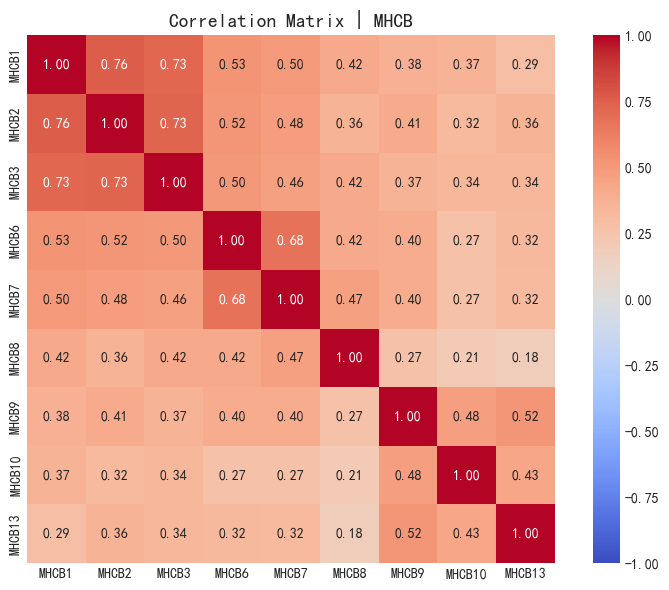

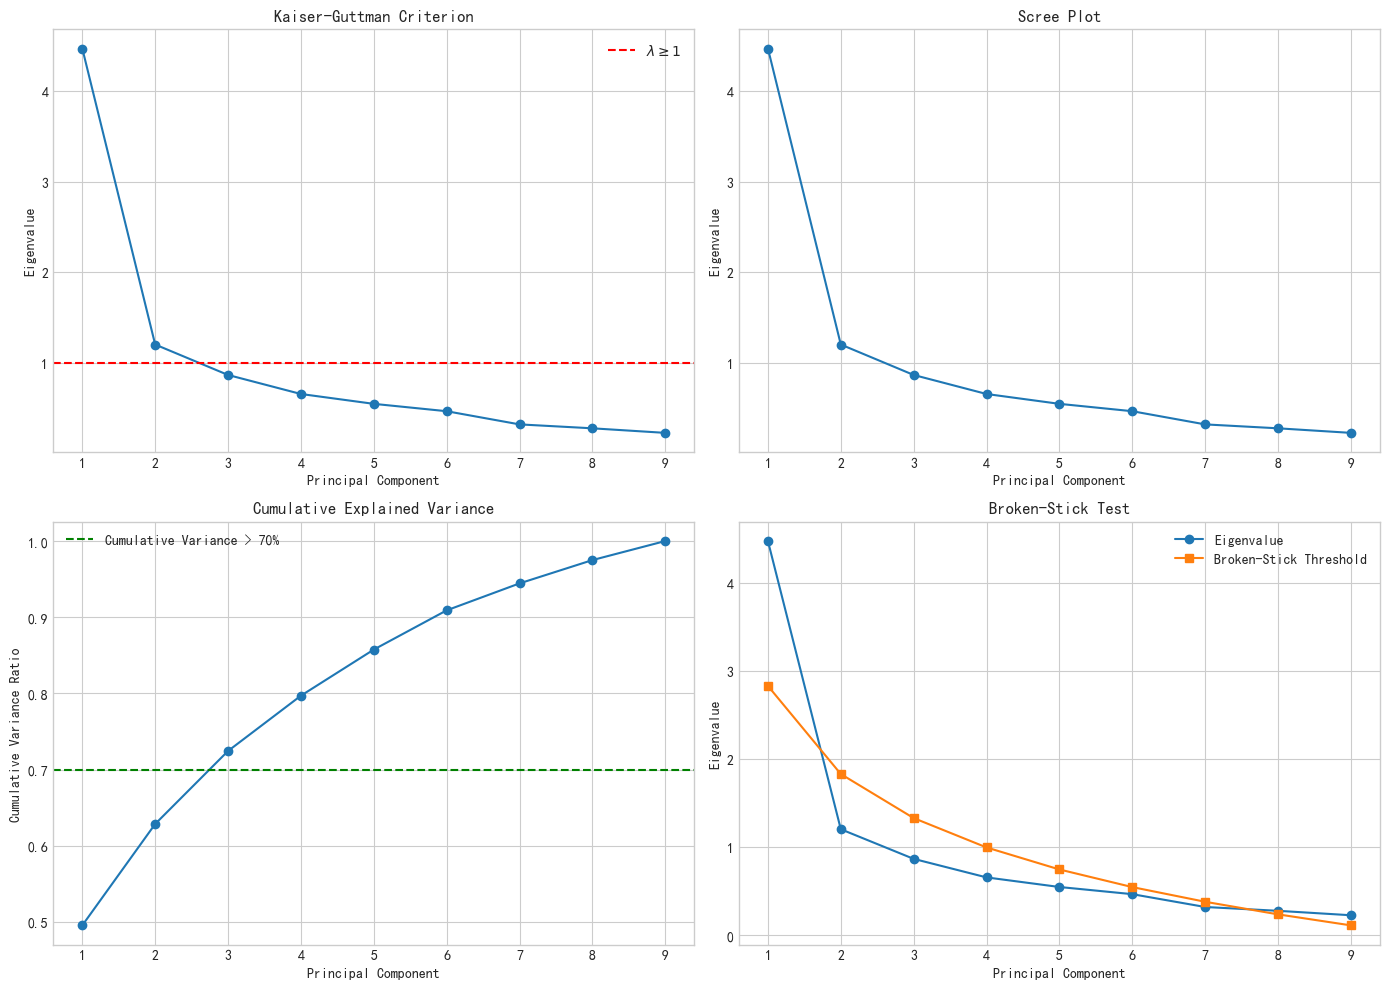

[MHCB] Retain two principal components, generate 2D charts...


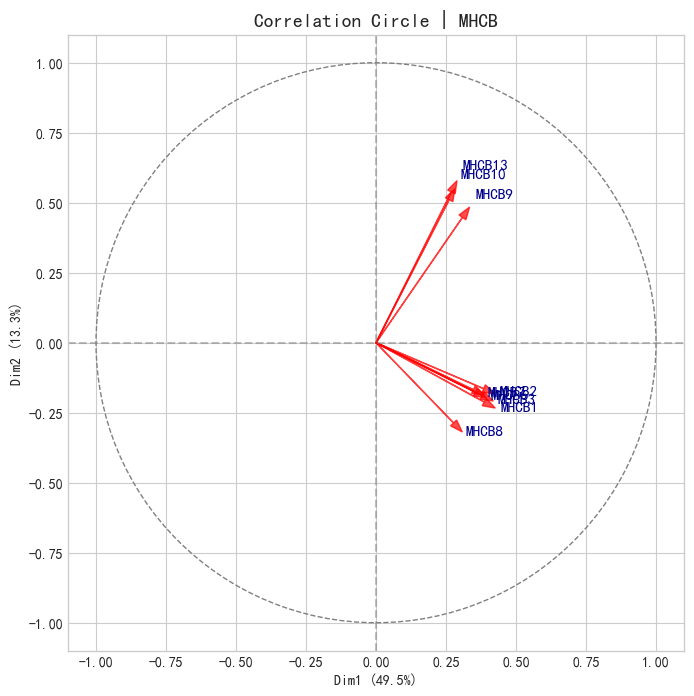

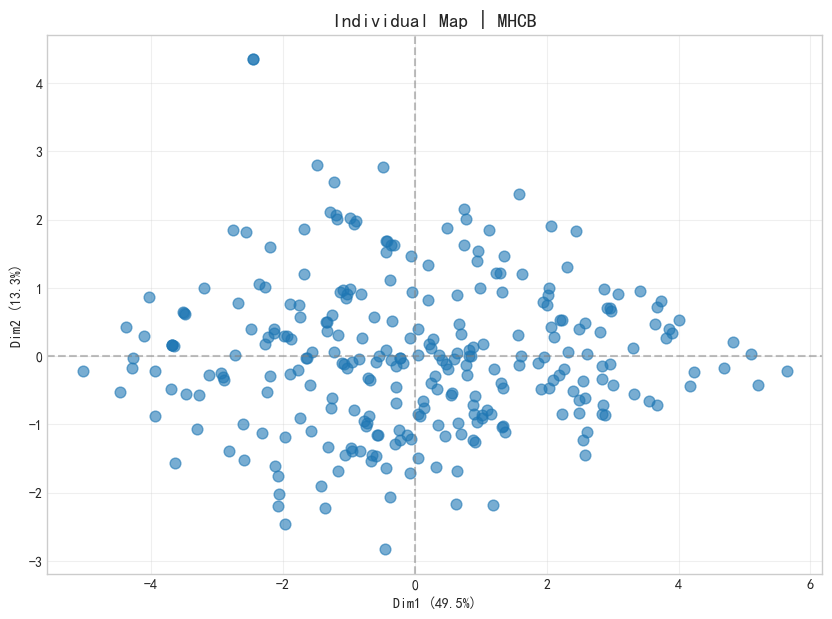

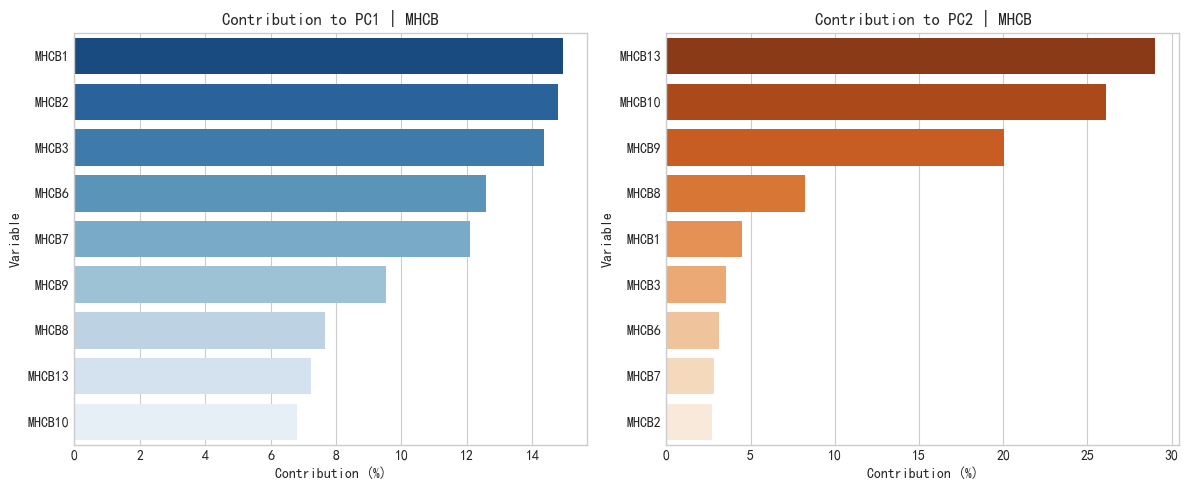


=== PCA Principal Component Analysis: MHCC ===


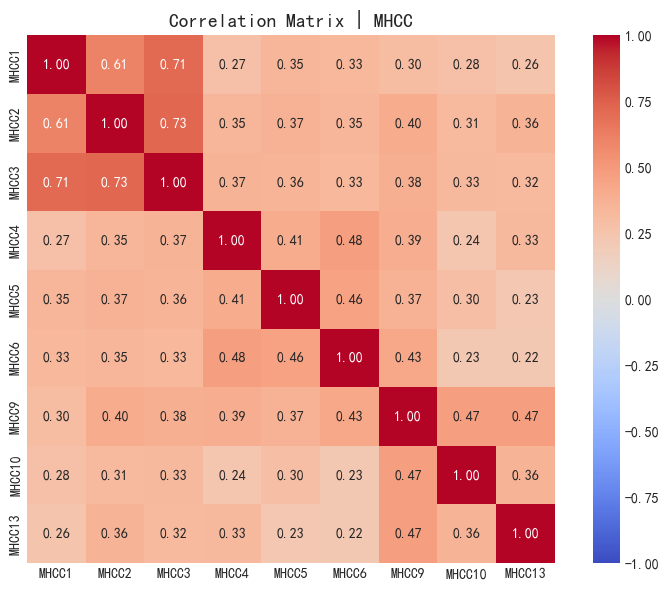

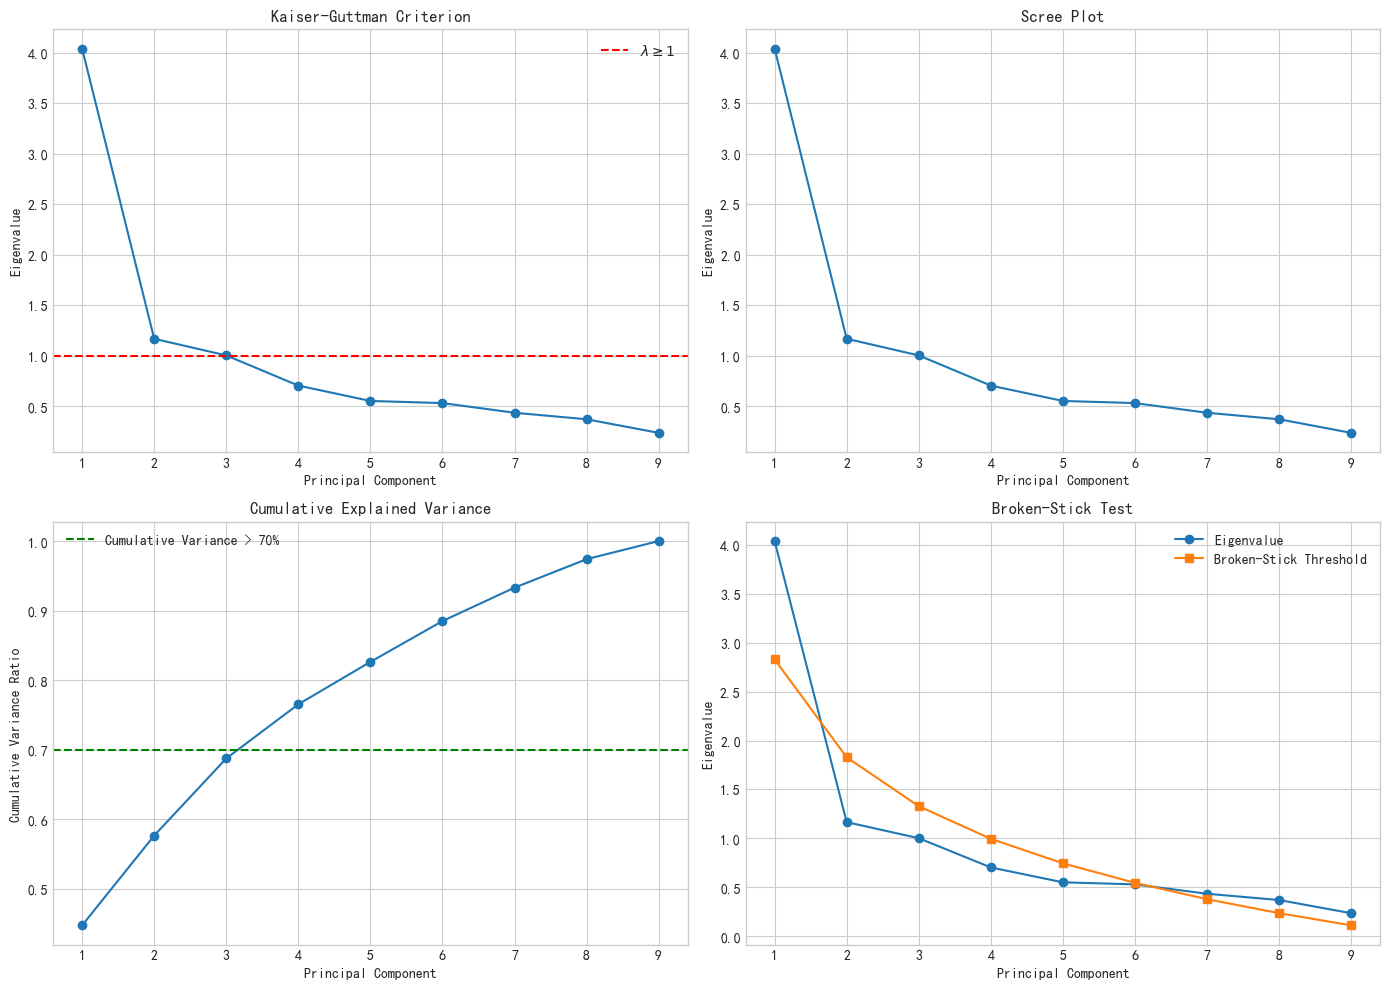

[MHCC] Retain two principal components, generate 2D charts...


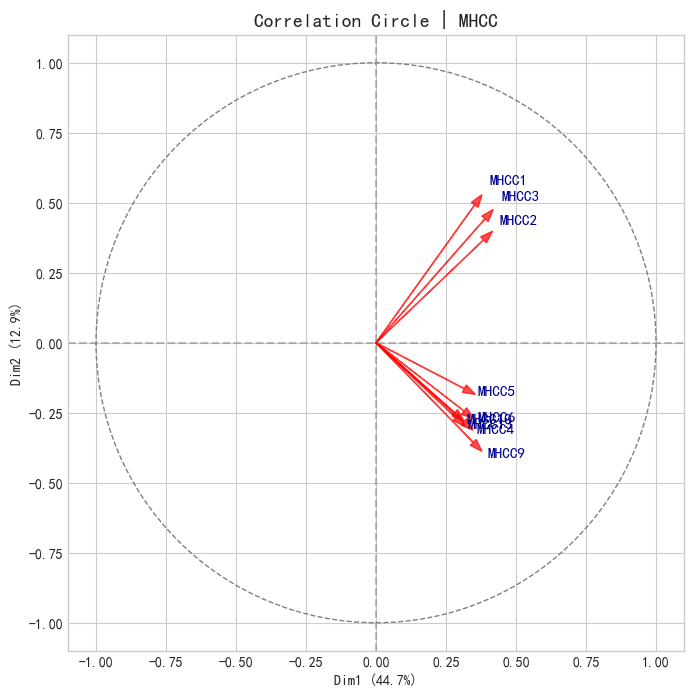

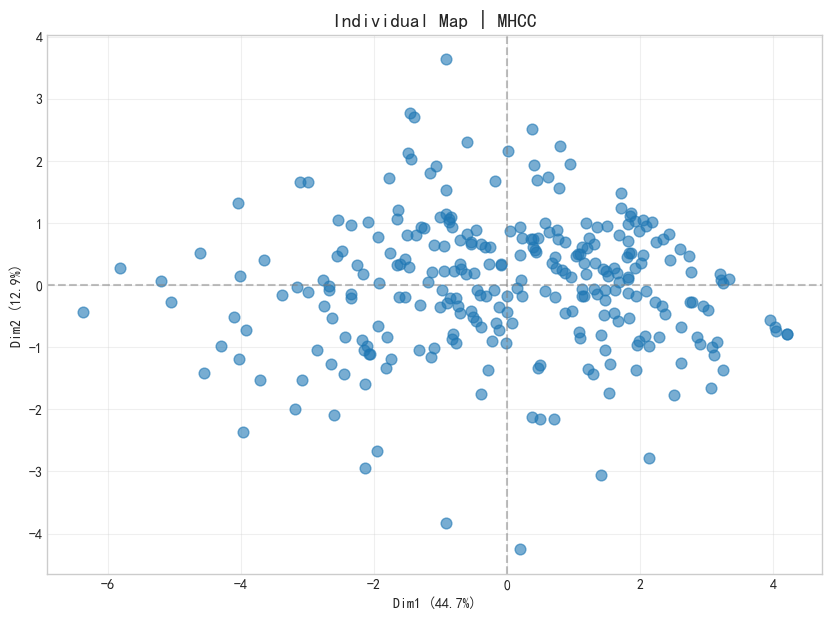

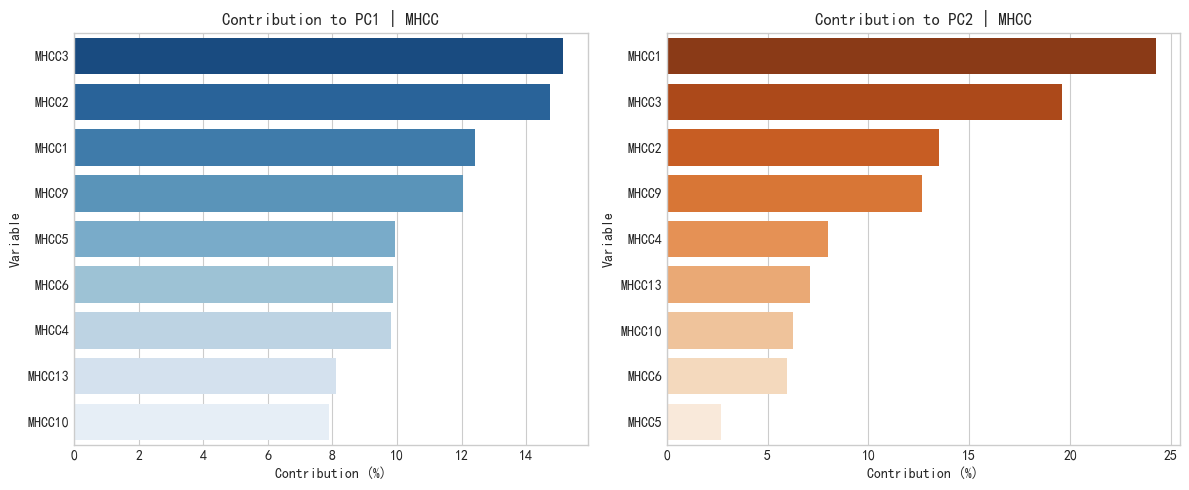


=== PCA Principal Component Analysis: PE ===


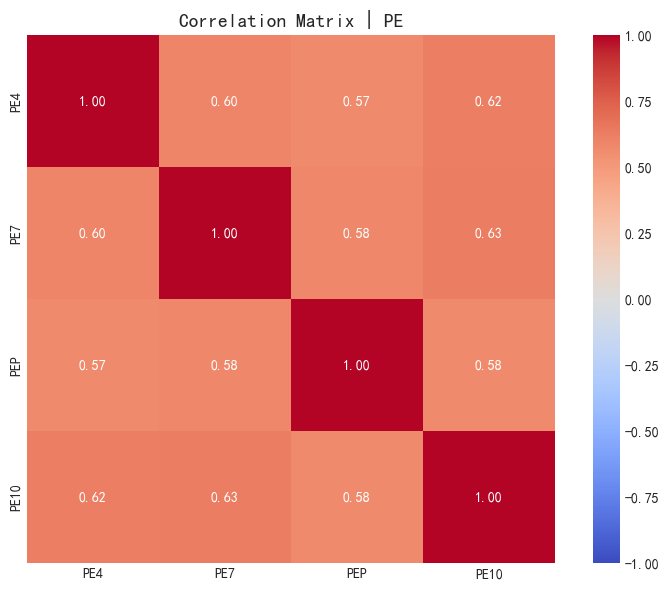

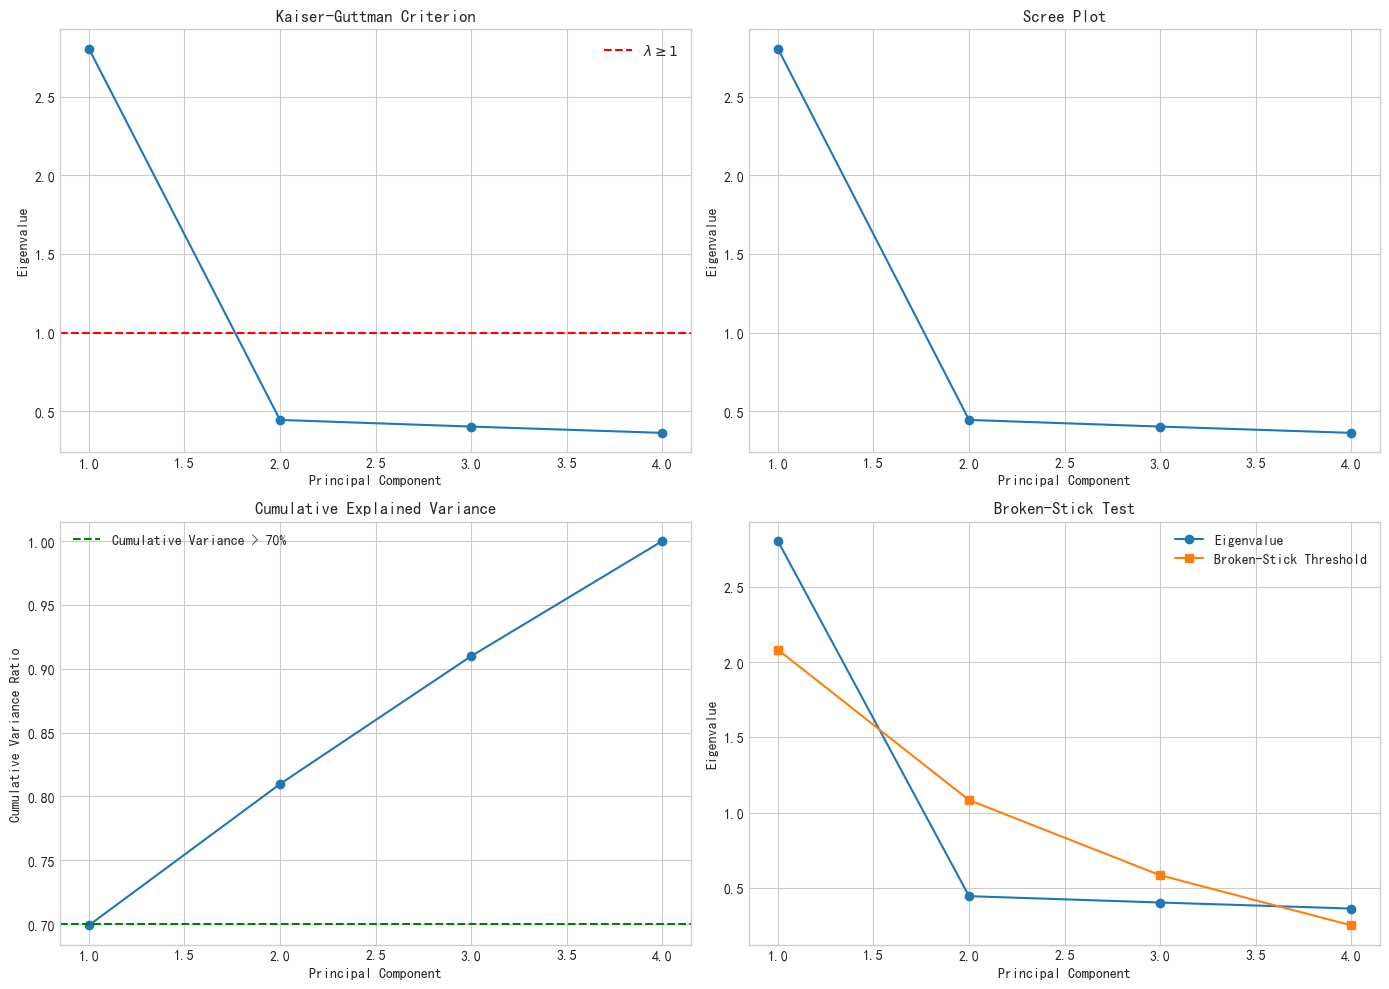

[PE] Shows strong unidimensionality, switching to 1D visualization chart...


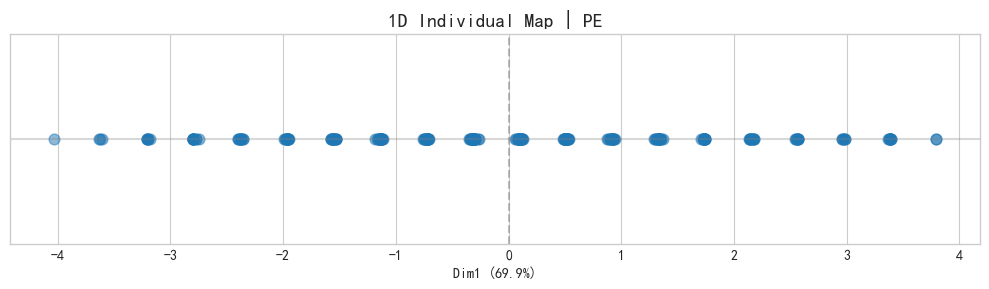

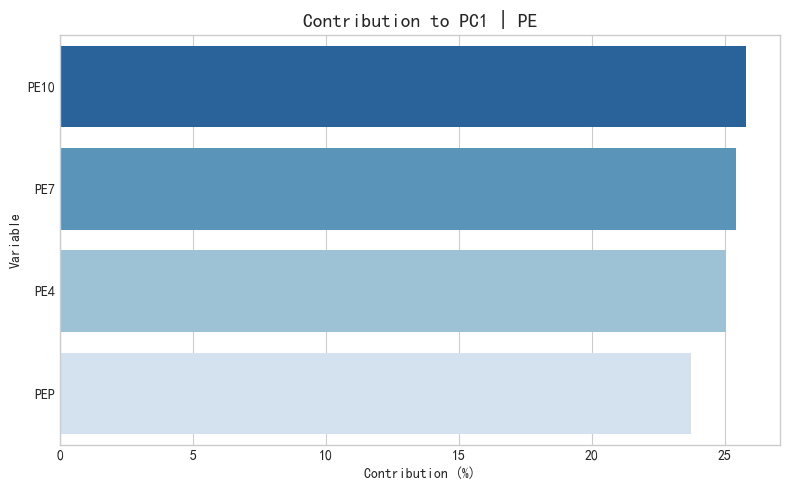


=== PCA Principal Component Analysis: NE ===


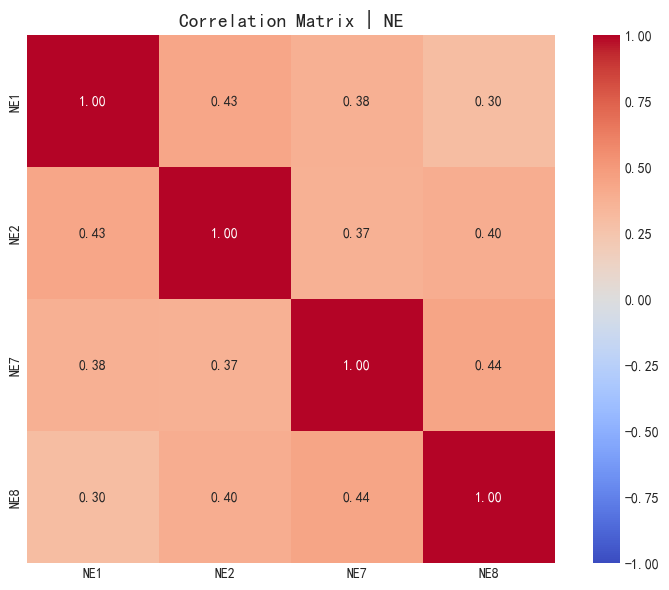

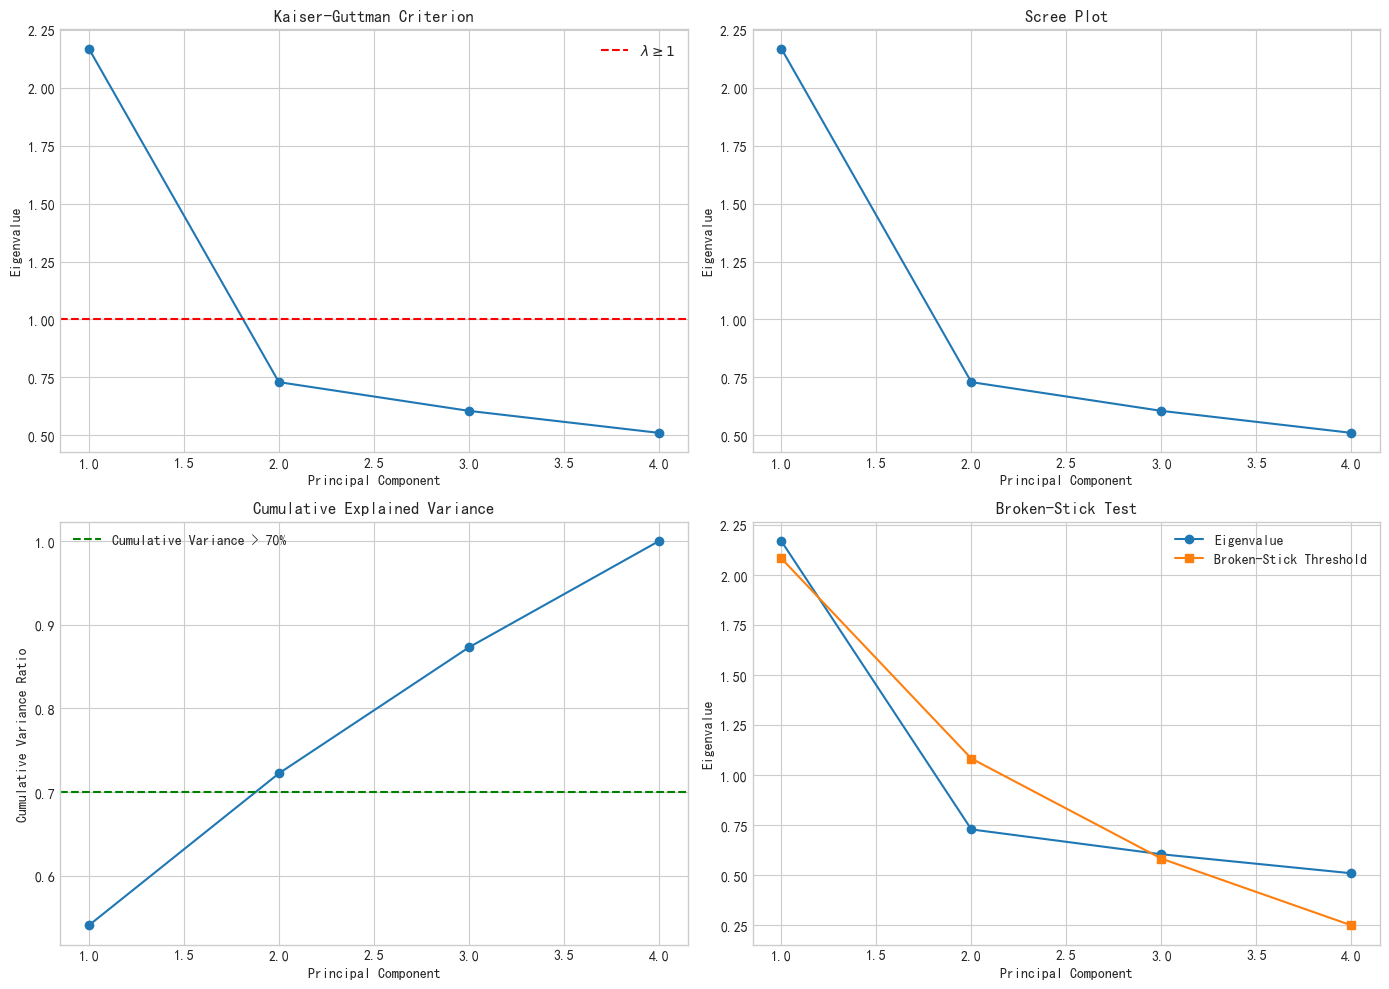

[NE] Retain two principal components, generate 2D charts...


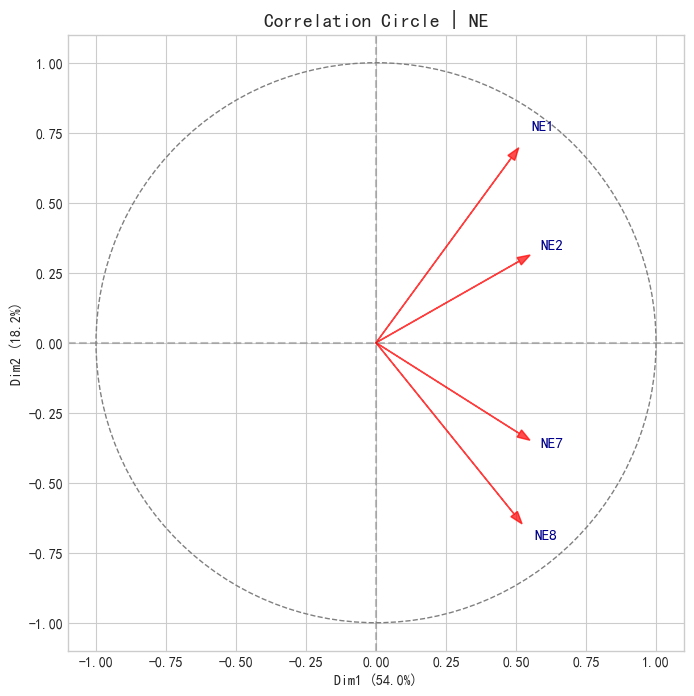

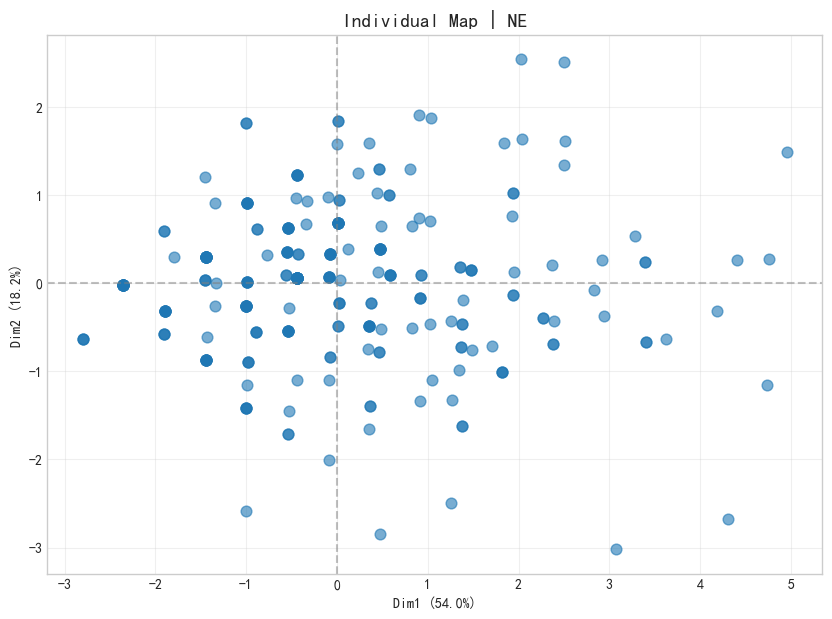

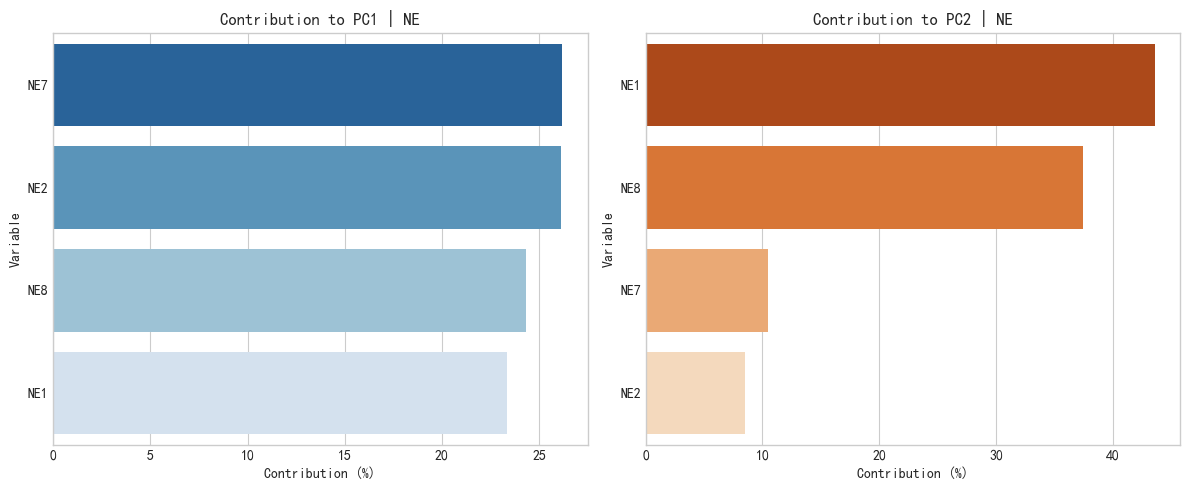


=== PCA Principal Component Analysis: Force ===


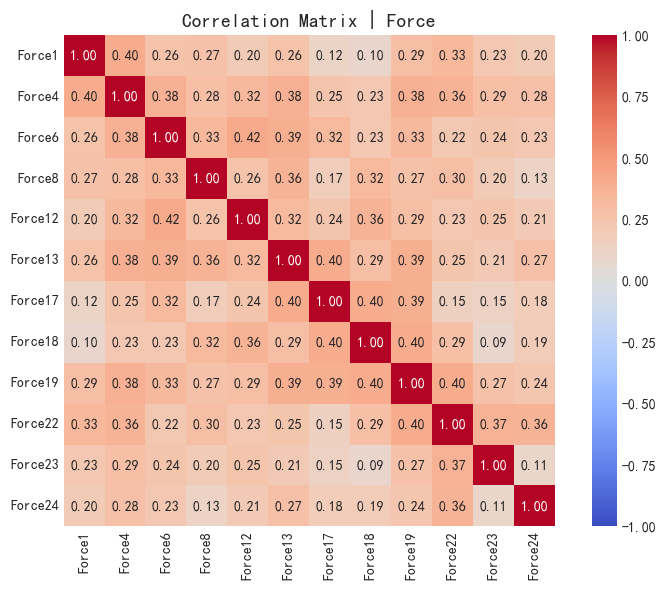

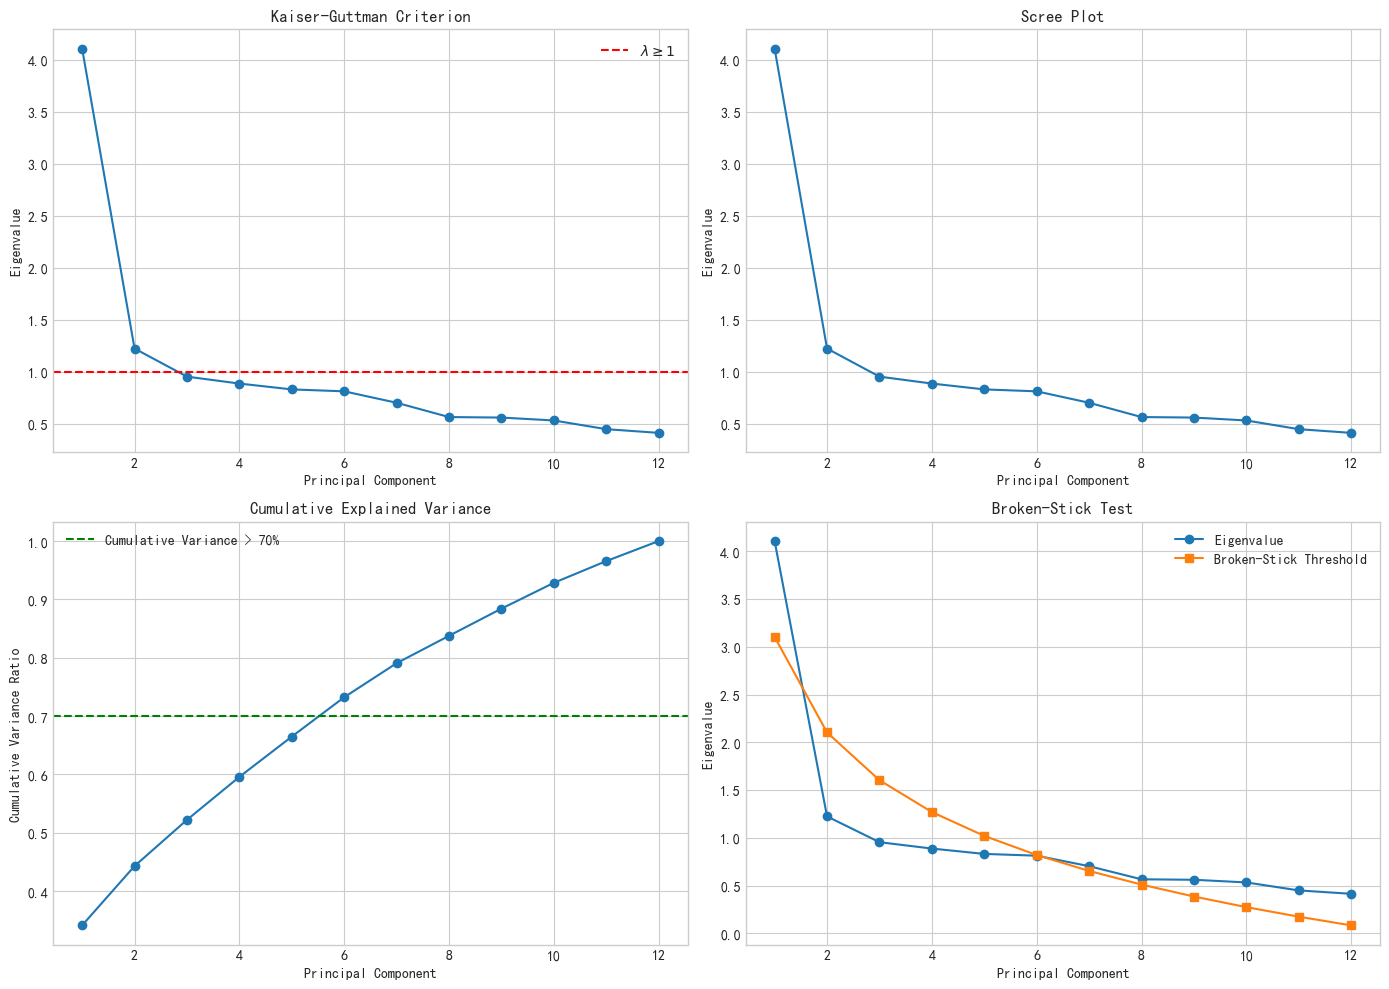

[Force] Retain two principal components, generate 2D charts...


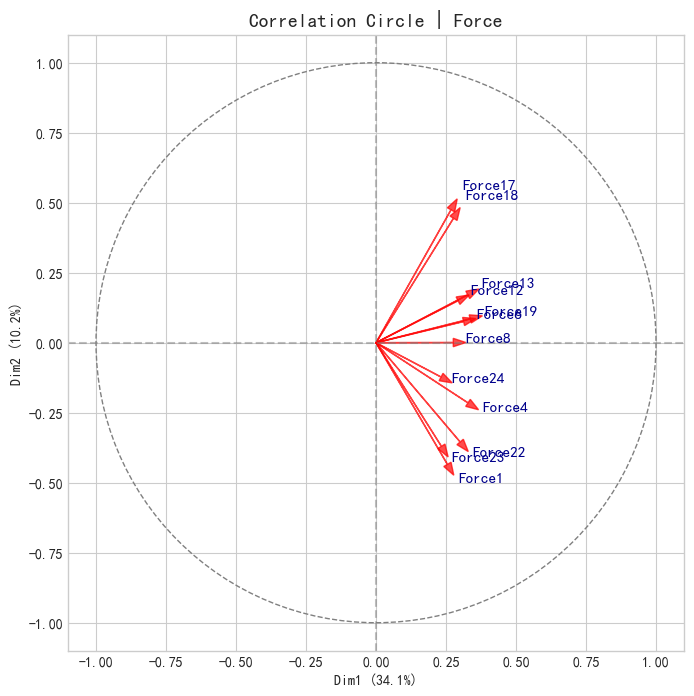

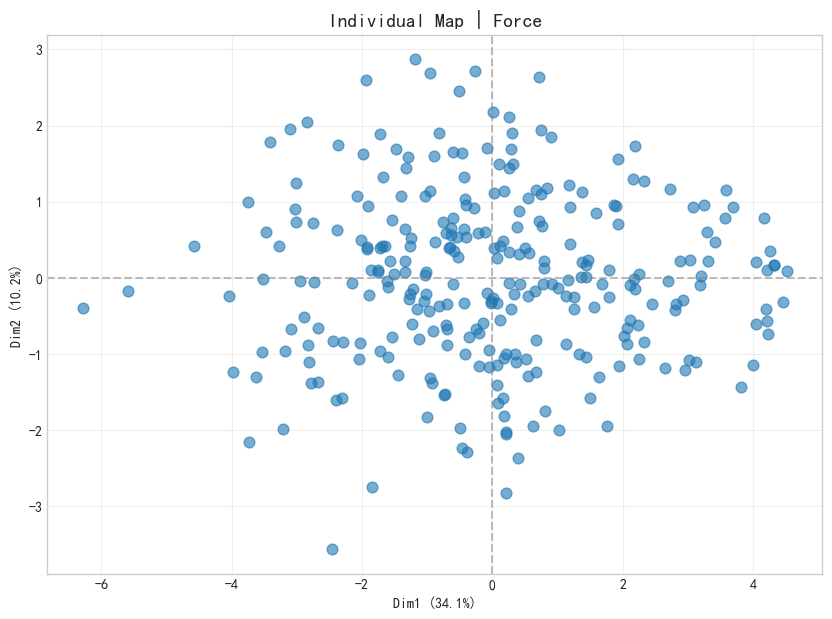

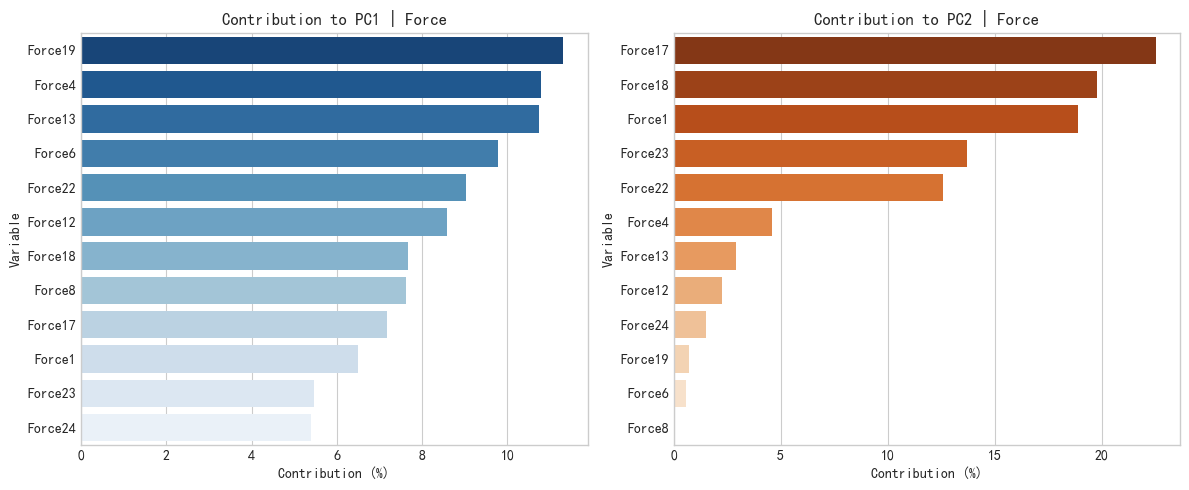


=== PCA Principal Component Analysis: FQ ===


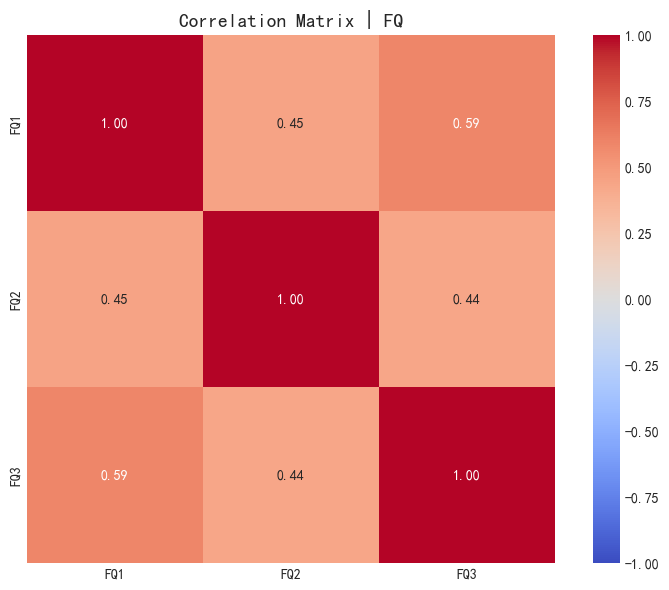

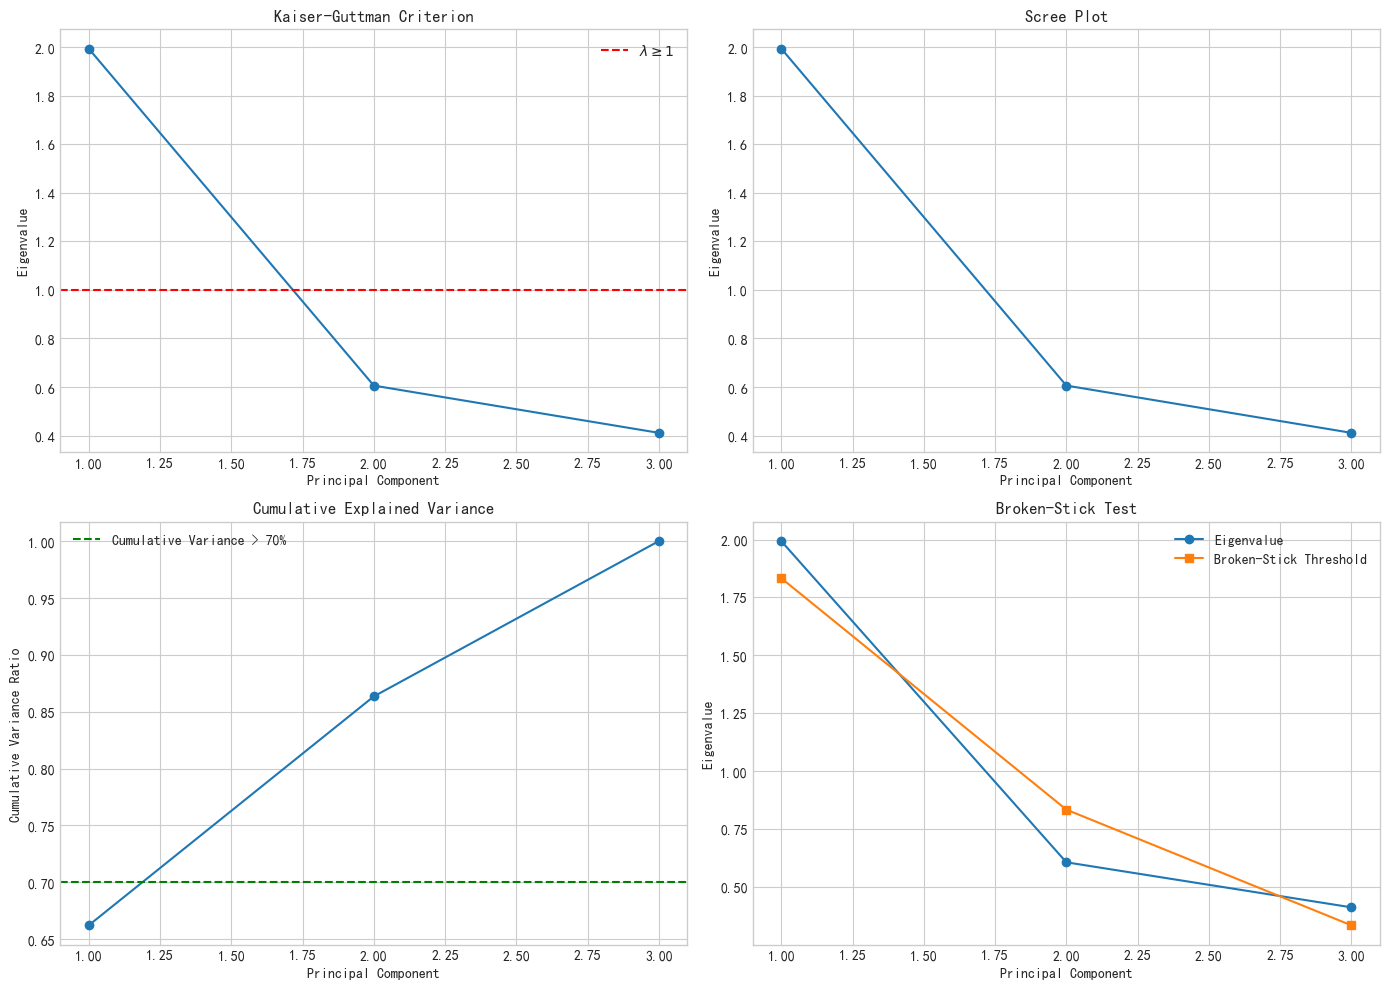

[FQ] Shows strong unidimensionality, switching to 1D visualization chart...


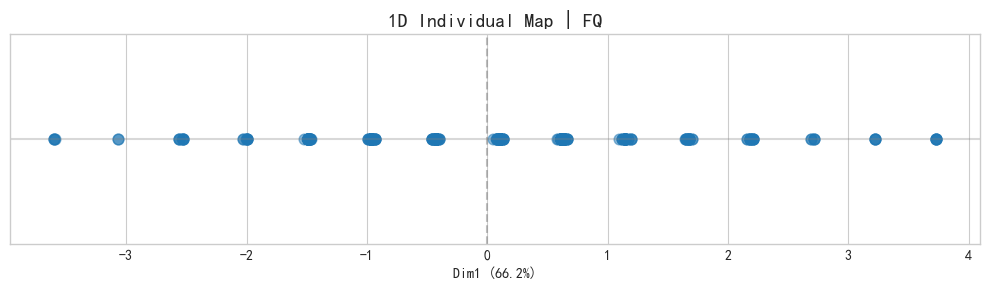

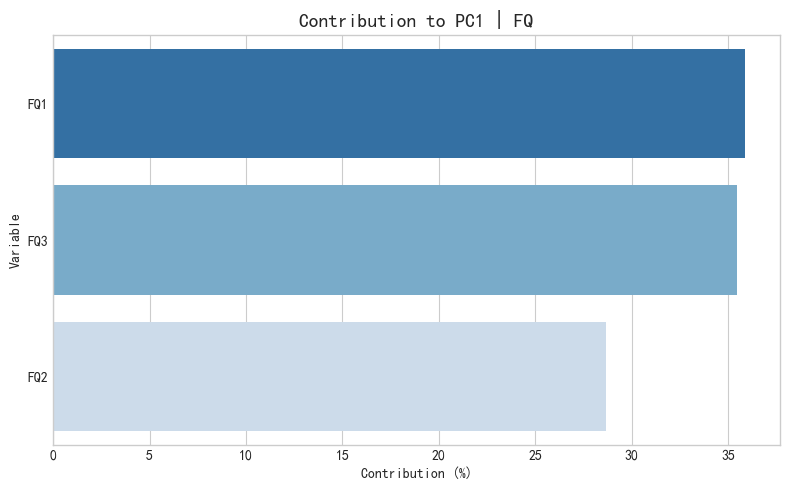


=== PCA Principal Component Analysis: Flux ===


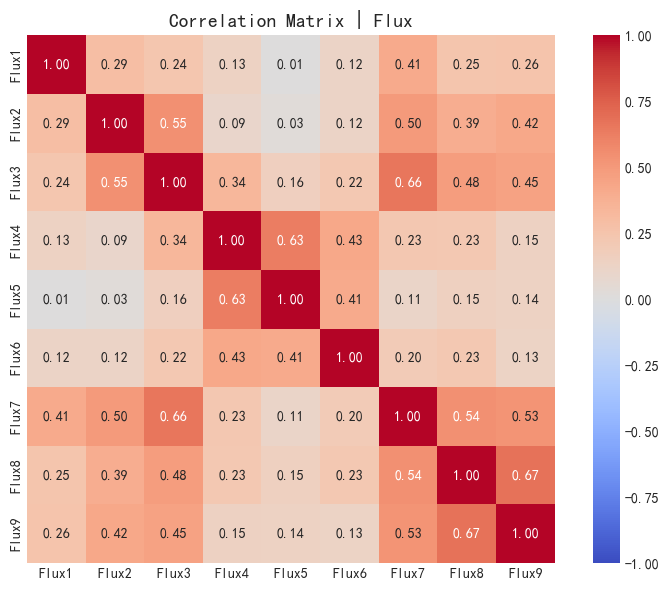

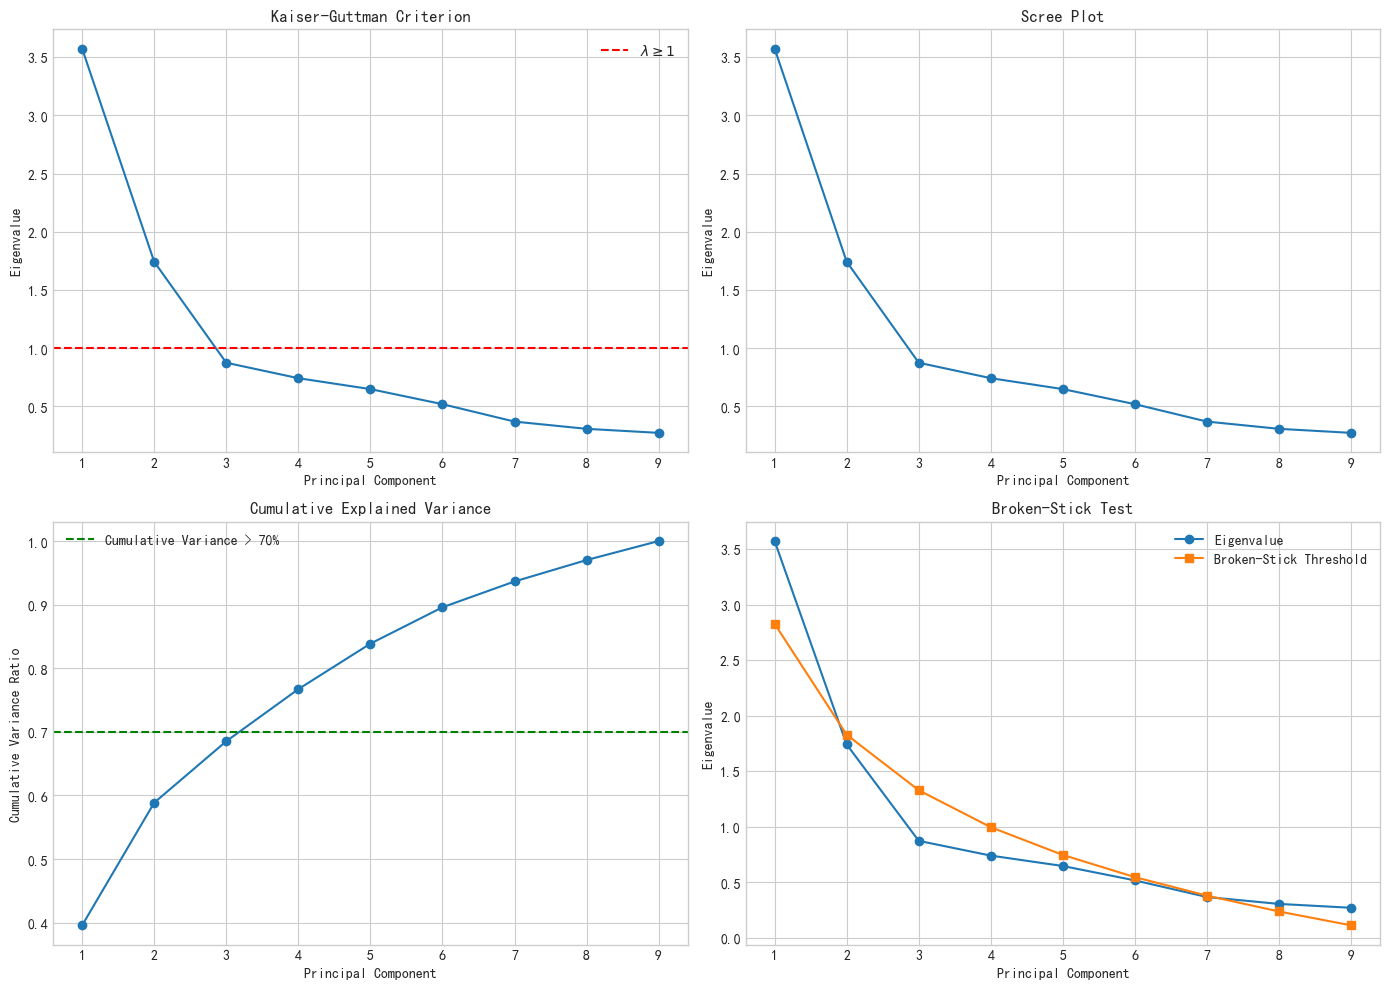

[Flux] Retain two principal components, generate 2D charts...


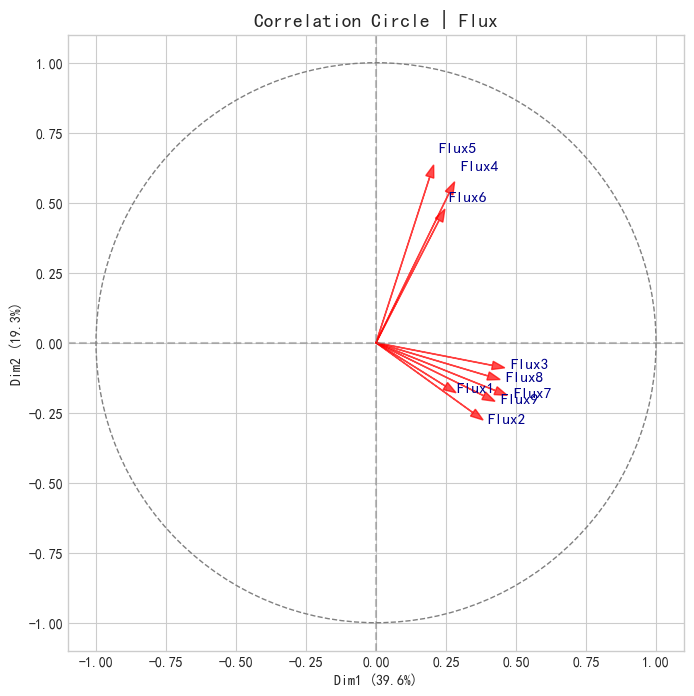

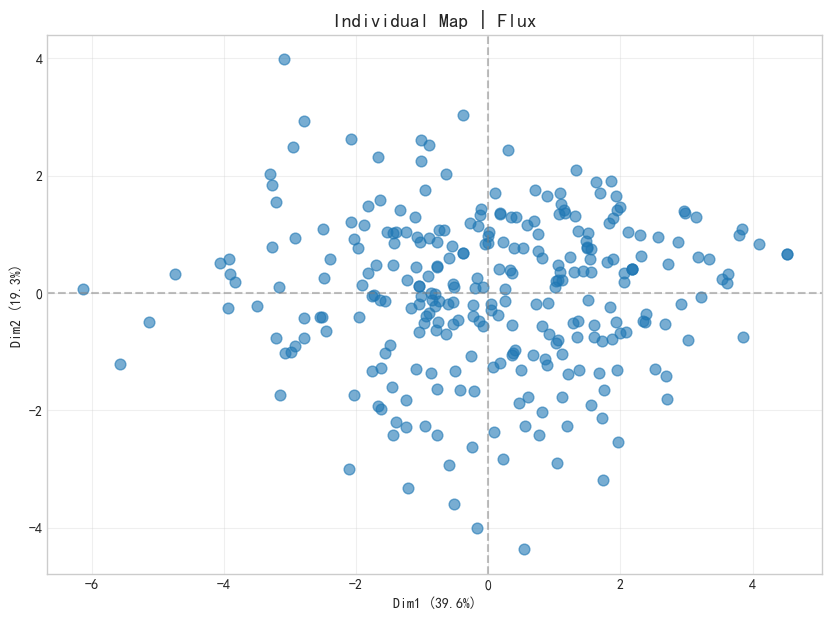

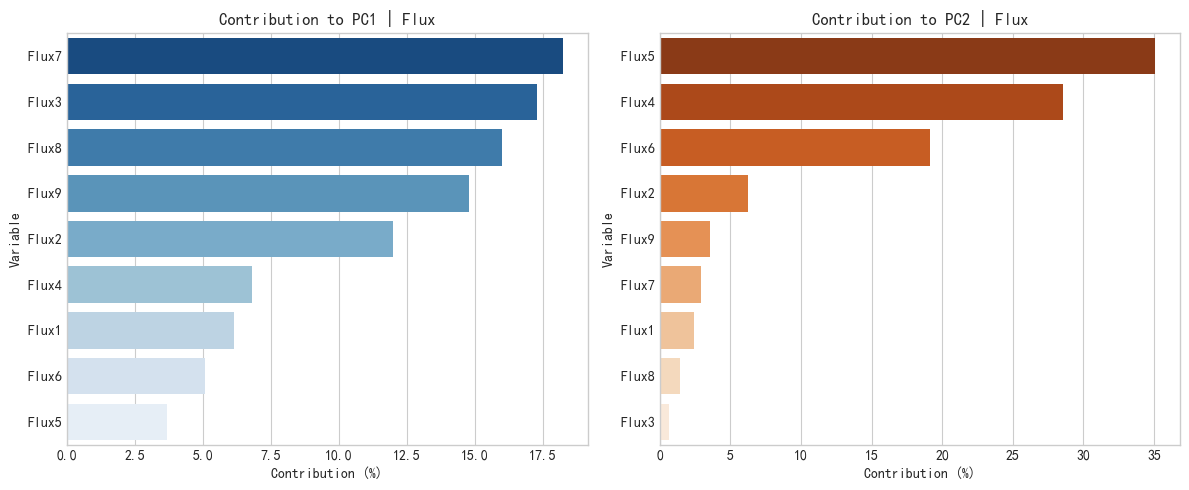


All analyses completed!


In [24]:
# 5. Principal Component Analysis (PCA) and Visualization
# Define column names based on scale themes
TOPICS = {
    "MHCB": [col for col in df.columns if col.startswith("MHCB") and "MHCB_func" not in col],
    "MHCC": [col for col in df.columns if col.startswith("MHCC") and "MHCC_func" not in col],
    "PE": [col for col in df.columns if col.startswith("PE")],
    "NE": [col for col in df.columns if col.startswith("NE")],
    "Force": [col for col in df.columns if col.startswith("Force")],
    "FQ": [col for col in df.columns if col.startswith("FQ")],
    "Flux": [col for col in df.columns if col.startswith("Flux")],
}

for topic_name, feature_list in TOPICS.items():
    # Keep only existing numeric variables in the dataset
    feature_list = [f for f in feature_list if f in df.columns and pd.api.types.is_numeric_dtype(df[f])]
    
    if len(feature_list) < 2:
        continue
        
    print("\n" + "=" * 70)
    print(f"=== PCA Principal Component Analysis: {topic_name} ===")
    
    # Extract data and standardize
    X = df[feature_list].dropna().copy()
    if len(X) == 0:
        continue
        
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    
    # Perform full-dimensional PCA (to plot complete scree plot)
    pca = PCA()
    pca.fit(Xs)
    loadings = pca.components_.T
    evr = pca.explained_variance_ratio_
    cum_evr = np.cumsum(evr)
    scores = pca.transform(Xs)
    
    # Figure 1: Correlation Heatmap
    plt.figure(figsize=(8, 6))
    corr = pd.DataFrame(Xs, columns=feature_list).corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
    plt.title(f"Correlation Matrix | {topic_name}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    eigenvalues = pca.explained_variance_
    p = len(eigenvalues)
    x_axis = range(1, p + 1)
    
    # Calculate Broken-Stick expected eigenvalues
    broken_stick = [sum(1.0 / j for j in range(i, p + 1)) for i in range(1, p + 1)]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Kaiser-Guttman Criterion
    axs[0, 0].plot(x_axis, eigenvalues, 'o-')
    axs[0, 0].axhline(y=1, color='r', linestyle='--', label=r'$\lambda \geq 1$')
    axs[0, 0].set_title('Kaiser-Guttman Criterion')
    axs[0, 0].set_xlabel('Principal Component')
    axs[0, 0].set_ylabel('Eigenvalue')
    axs[0, 0].legend()

    # 2. Scree Plot
    axs[0, 1].plot(x_axis, eigenvalues, 'o-')
    axs[0, 1].set_title('Scree Plot')
    axs[0, 1].set_xlabel('Principal Component')
    axs[0, 1].set_ylabel('Eigenvalue')

    # 3. Cumulative Explained Variance Ratio
    axs[1, 0].plot(x_axis, cum_evr, 'o-')
    axs[1, 0].axhline(y=0.7, color='g', linestyle='--', label='Cumulative Variance > 70%')
    axs[1, 0].set_title('Cumulative Explained Variance')
    axs[1, 0].set_xlabel('Principal Component')
    axs[1, 0].set_ylabel('Cumulative Variance Ratio')
    axs[1, 0].legend()

    # 4. Broken-Stick Test
    axs[1, 1].plot(x_axis, eigenvalues, 'o-', label='Eigenvalue')
    axs[1, 1].plot(x_axis, broken_stick, 's-', label='Broken-Stick Threshold')
    axs[1, 1].set_title('Broken-Stick Test')
    axs[1, 1].set_xlabel('Principal Component')
    axs[1, 1].set_ylabel('Eigenvalue')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

    if topic_name in ["PE", "FQ"]:
        n_keep = 1
    elif topic_name in ["MHCB", "MHCC", "NE", "Force", "Flux"]:
        n_keep = 2
    else:
        n_keep = 2
        
    if n_keep == 1:
        print(f"[{topic_name}] Shows strong unidimensionality, switching to 1D visualization chart...")
        
        # Figure 3A (1D): 1D Individual Map
        plt.figure(figsize=(10, 3))
        plt.scatter(scores[:, 0], np.zeros_like(scores[:, 0]), color='#1f77b4', s=60, alpha=0.5)
        plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
        plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
        plt.xlabel(f"Dim1 ({evr[0]*100:.1f}%)")
        plt.yticks([])
        plt.title(f"1D Individual Map | {topic_name}", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Figure 4A (1D): Single dimension variable contribution plot
        contrib = pd.DataFrame({
            'Variable': feature_list,
            'Contrib_PC1': (loadings[:, 0] ** 2) * 100
        })
        plt.figure(figsize=(8, 5))
        sns.barplot(y='Variable', x='Contrib_PC1', data=contrib.sort_values('Contrib_PC1', ascending=False), hue='Variable', palette='Blues_r', legend=False)
        plt.title(f"Contribution to PC1 | {topic_name}", fontsize=14)
        plt.xlabel("Contribution (%)")
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"[{topic_name}] Retain two principal components, generate 2D charts...")
        
        # Figure 3B (2D): Correlation Circle
        fig, ax = plt.subplots(figsize=(8, 8))
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
        ax.add_patch(circle)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        
        for i, var in enumerate(feature_list):
            x = loadings[i, 0]
            y = loadings[i, 1]
            ax.arrow(0, 0, x, y, head_width=0.03, color='red', alpha=0.7)
            ax.text(x*1.15, y*1.15, var, fontsize=11, color='darkblue')
            
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')
        ax.set_xlabel(f"Dim1 ({evr[0]*100:.1f}%)")
        ax.set_ylabel(f"Dim2 ({evr[1]*100:.1f}%)")
        plt.title(f"Correlation Circle | {topic_name}", fontsize=14)
        plt.show()
        
        # Figure 4B (2D): 2D Individual Score Map (Individual Map)
        plt.figure(figsize=(10, 7))
        plt.scatter(scores[:, 0], scores[:, 1], color='#1f77b4', s=60, alpha=0.6)
        plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
        plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
        plt.xlabel(f"Dim1 ({evr[0]*100:.1f}%)")
        plt.ylabel(f"Dim2 ({evr[1]*100:.1f}%)")
        plt.title(f"Individual Map | {topic_name}", fontsize=14)
        plt.grid(alpha=0.3)
        plt.show()
        
        # Figure 5B (2D): Two principal components contribution plot
        contrib = pd.DataFrame({
            'Variable': feature_list,
            'Contrib_PC1': (loadings[:, 0] ** 2) * 100,
            'Contrib_PC2': (loadings[:, 1] ** 2) * 100
        })
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.barplot(y='Variable', x='Contrib_PC1', data=contrib.sort_values('Contrib_PC1', ascending=False), hue='Variable', palette='Blues_r', legend=False)
        plt.title(f"Contribution to PC1 | {topic_name}")
        plt.xlabel("Contribution (%)")
        
        plt.subplot(1, 2, 2)
        sns.barplot(y='Variable', x='Contrib_PC2', data=contrib.sort_values('Contrib_PC2', ascending=False), hue='Variable', palette='Oranges_r', legend=False)
        plt.title(f"Contribution to PC2 | {topic_name}")
        plt.xlabel("Contribution (%)")
        
        plt.tight_layout()
        plt.show()

print("\nAll analyses completed!")